# 05 · O seu modelo: Detecção de Fraude e Risco de Crédito

**Workshop Matriz de Confiança · Bloco 5 e 6**

Este notebook executa o framework completo da Matriz de Confiança sobre o desafio do squad: **previsão de inadimplência e fraude em solicitações de crédito pessoal** (`dataset_desafio_credito.csv`).

### Roteiro Completo do Notebook:
1. **Passo 1 · Dados e Divisão Sem Vazamento**: Carregamento de 18.000 registros e divisão em Treino base (52,5%), Validação de calibração (17,5%) e Teste intocado (30%).
2. **Passo 2 · Modelos Base (Regressão Logística vs Random Forest)**: Treinamento e avaliação no limiar padrão ($t=0,5$), demonstrando a armadilha da acurácia.
3. **Passo 3 · Fatiamento por Subgrupos**: Análise por Canal (`App`, `Agência`, `Correspondente`) e Região (`Norte`, `Sudeste`, etc.).
4. **Passo 4 · Custo e Limiar Operacional Ótimo**: Otimização contínua sob a razão de custo 20:1 ($C_{FN} = 	ext{R\$} 2.000$, $C_{FP} = 	ext{R\$} 100$).
5. **Passo 5 · Calibração de Probabilidades**: Diagnóstico com ECE/Brier e Curvas de Confiabilidade em `X_val`.
6. **Passo 6 · Incerteza e Abstenção**: Margem ao limiar $|p - t^*|$ e dimensionamento da Mesa Humana de Risco.
7. **Passo 7 · Brainstorming de Engenharia de Features**: Hipóteses de crédito e criação de 11 novas features de solvência, alavancagem e estresse.
8. **Passo 8 · Comparativo Completo com Features**: Ambos os modelos 100% treinados com as novas features.
9. **Passo 9 · Storytelling e Decisões de Arquitetura**: Como as features reduziram os falsos positivos e a proposta da Esteira de 3 Zonas.

## Passo 1 — Carregamento dos dados e Divisão Estratificada

Carregamos o dataset de crédito e realizamos o split estratificado do workshop:
- `X_te`, `y_te`: 5.400 casos (30%) para avaliação final intocada.
- `X_val`, `y_val`: 3.150 casos (17,5%) para calibração de probabilidades.
- `X_tr2`, `y_tr2`: 9.450 casos (52,5%) para treinamento dos modelos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, matthews_corrcoef,
                             roc_auc_score, average_precision_score,
                             precision_score, recall_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

# 1. Carregamento dos dados
df = pd.read_csv('dataset_desafio_credito.csv')
X_base = df.drop(columns=['id_solicitacao', 'inadimplente'])
y = df['inadimplente'].values

# 2. Split canônico sem vazamento
X_tr_b, X_te_b, y_tr, y_te = train_test_split(X_base, y, test_size=0.3, stratify=y, random_state=42)
X_tr2_b, X_val_b, y_tr2, y_val = train_test_split(X_tr_b, y_tr, test_size=0.25, stratify=y_tr, random_state=42)

cat_cols = ['canal', 'regiao']
num_cols_b = [c for c in X_base.columns if c not in cat_cols]

print(f"Total dataset:           {len(df)} registros")
print(f"Treino base (X_tr2):     {len(X_tr2_b)} registros ({len(X_tr2_b)/len(df):.1%})")
print(f"Calibração (X_val):      {len(X_val_b)} registros ({len(X_val_b)/len(df):.1%})")
print(f"Teste final (X_te):      {len(X_te_b)} registros ({len(X_te_b)/len(df):.1%})")
print(f"Prevalência de Fraude:   {y.mean():.2%} ({int(y.sum())} fraudes no total, {int(y_te.sum())} no teste)")

Total dataset:           18000 registros
Treino base (X_tr2):     9450 registros (52.5%)
Calibração (X_val):      3150 registros (17.5%)
Teste final (X_te):      5400 registros (30.0%)
Prevalência de Fraude:   7.72% (1390 fraudes no total, 417 no teste)


## Passo 2 — Treinamento dos Modelos Base e Armadilha do Limiar 0,5

Treinamos a **Regressão Logística** e a **Random Forest** nos dados base:
- Avaliamos a matriz de confusão e métricas no limiar default $t=0,5$.
- Comparamos o poder discriminatório (ROC e Precision-Recall).

=== COMPARAÇÃO NO LIMIAR PADRÃO (t = 0,50) ===
Regressão Logística -> VN=4964 | FP=19 | FN=396 | VP=21 | Recall=5.04% | Acurácia=92.31%
Random Forest       -> VN=4974 | FP=9 | FN=413 | VP=4 | Recall=0.96% | Acurácia=92.19%

ATENÇÃO: A acurácia aparente de 92% é uma ilusão de classe majoritária!
Ambos os modelos no limiar 0,5 deixam passar mais de 99% das fraudes!


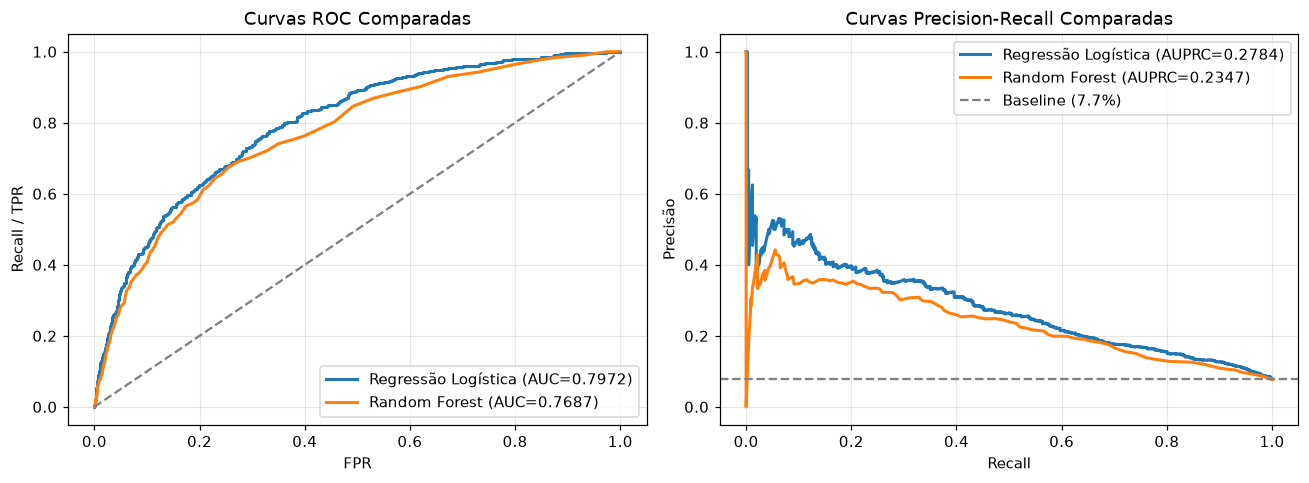

In [ ]:
# Definição dos pipelines
prep_lr_b = ColumnTransformer([
    ('num', StandardScaler(), num_cols_b),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

prep_rf_b = ColumnTransformer([
    ('num', 'passthrough', num_cols_b),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

clf_lr_b = Pipeline([('prep', prep_lr_b), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
clf_rf_b = Pipeline([('prep', prep_rf_b), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])

# Treinamento nos dados base
clf_lr_b.fit(X_tr2_b, y_tr2)
clf_rf_b.fit(X_tr2_b, y_tr2)

# Probabilidades de teste
p_lr_b = clf_lr_b.predict_proba(X_te_b)[:, 1]
p_rf_b = clf_rf_b.predict_proba(X_te_b)[:, 1]

# Avaliação no Limiar Padrão t = 0,5
pred_lr_05 = (p_lr_b >= 0.5).astype(int)
pred_rf_05 = (p_rf_b >= 0.5).astype(int)

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_te, pred_lr_05).ravel()
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_te, pred_rf_05).ravel()

print("=== COMPARAÇÃO NO LIMIAR PADRÃO (t = 0,50) ===")
print(f"Regressão Logística -> VN={tn_lr} | FP={fp_lr} | FN={fn_lr} | VP={tp_lr} | Recall={recall_score(y_te, pred_lr_05):.2%} | Acurácia={(tp_lr+tn_lr)/len(y_te):.2%}")
print(f"Random Forest       -> VN={tn_rf} | FP={fp_rf} | FN={fn_rf} | VP={tp_rf} | Recall={recall_score(y_te, pred_rf_05):.2%} | Acurácia={(tp_rf+tn_rf)/len(y_te):.2%}")
print("\nATENÇÃO: A acurácia aparente de 92% é uma ilusão de classe majoritária!")
print("Ambos os modelos no limiar 0,5 deixam passar mais de 99% das fraudes!")

# Gráficos ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in [('Regressão Logística', p_lr_b), ('Random Forest', p_rf_b)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_te, p):.4f})")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('Curvas ROC Comparadas'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('Recall / TPR')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

for name, p in [('Regressão Logística', p_lr_b), ('Random Forest', p_rf_b)]:
    prec, rec, _ = precision_recall_curve(y_te, p)
    axes[1].plot(rec, prec, lw=2, label=f"{name} (AUPRC={average_precision_score(y_te, p):.4f})")
axes[1].axhline(y_te.mean(), ls='--', color='gray', label=f'Baseline ({y_te.mean():.1%})')
axes[1].set_title('Curvas Precision-Recall Comparadas'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisão')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### ✏️ Tradução de Falsos Positivos e Falsos Negativos com impacto de negócio

- **Falso Positivo:** O cliente legítimo *Carlos Eduardo* tenta contratar um empréstimo pessoal de R$ 15.000 pelo App para reformar sua pequena oficina, mas o modelo o bloqueia sumariamente como fraude. Consequência: constrangimento injustificado, perda de confiança e churn irreversível para o concorrente.
- **Falso Negativo:** O fraudador *Marcos Vinicius* solicita R$ 22.000 com documentos forjados e sem intenção de pagamento, e o modelo o aprova automaticamente como legítimo. Consequência: saque integral imediato e prejuízo patrimonial líquido irrecuperável de R$ 22.000 para a instituição financeira.

## Passo 3 — Fatiamento por Subgrupos (Canal e Região)

Avaliamos a performance segmentada para detectar se alguma região ou canal sofre com quedas de performance localizada.

In [ ]:
print("=== RECALL POR CANAL (t = 0,50) ===")
for canal in np.unique(X_te_b['canal']):
    m = (X_te_b['canal'] == canal).values
    rec_lr = recall_score(y_te[m], pred_lr_05[m], zero_division=0)
    rec_rf = recall_score(y_te[m], pred_rf_05[m], zero_division=0)
    print(f"Canal {canal:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | Recall LR={rec_lr:.2%} | Recall RF={rec_rf:.2%}")

print("\n=== RECALL POR REGIÃO (t = 0,50) ===")
for reg in np.unique(X_te_b['regiao']):
    m = (X_te_b['regiao'] == reg).values
    rec_lr = recall_score(y_te[m], pred_lr_05[m], zero_division=0)
    rec_rf = recall_score(y_te[m], pred_rf_05[m], zero_division=0)
    print(f"Região {reg:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | Recall LR={rec_lr:.2%} | Recall RF={rec_rf:.2%}")

=== RECALL POR CANAL (t = 0,50) ===
Canal Agência         | n= 1581 | fraudes=110 | Recall LR=4.55% | Recall RF=1.82%
Canal App             | n= 2956 | fraudes=241 | Recall LR=4.56% | Recall RF=0.41%
Canal Correspondente  | n=  863 | fraudes= 66 | Recall LR=7.58% | Recall RF=1.52%

=== RECALL POR REGIÃO (t = 0,50) ===
Região Centro-Oeste    | n=  450 | fraudes= 39 | Recall LR=7.69% | Recall RF=0.00%
Região Nordeste        | n= 1421 | fraudes=109 | Recall LR=6.42% | Recall RF=0.00%
Região Norte           | n=  477 | fraudes= 36 | Recall LR=2.78% | Recall RF=0.00%
Região Sudeste         | n= 2316 | fraudes=168 | Recall LR=5.36% | Recall RF=1.19%
Região Sul             | n=  736 | fraudes= 65 | Recall LR=1.54% | Recall RF=3.08%


## Passo 4 — Custo e Limiar Operacional Ótimo

Aplicamos a matriz de custo de negócio:
- $C_{FN} = 	ext{R\$} 2.000$ (perda líquida por fraude consumada)
- $C_{FP} = 	ext{R\$} 100$ (custo de atrito e verificação)
- Razão: **20 : 1**  ·  Limiar Teórico $t^* = rac{C_{FP}}{C_{FP} + C_{FN}} pprox 0,0476$

=== OTIMIZAÇÃO DE CUSTO E LIMIAR OPERACIONAL ===
Regressão Logística -> Limiar Ótimo: t* = 0.0410 | Custo Total: R$ 338,700 (vs R$ 793,900 em 0,5 | Economia: 57.3%)
Random Forest       -> Limiar Ótimo: t* = 0.0460 | Custo Total: R$ 373,100 (vs R$ 826,900 em 0,5 | Economia: 54.9%)

Vantagem da Regressão Logística sobre a Random Forest: Economia adicional de R$ 34,400!


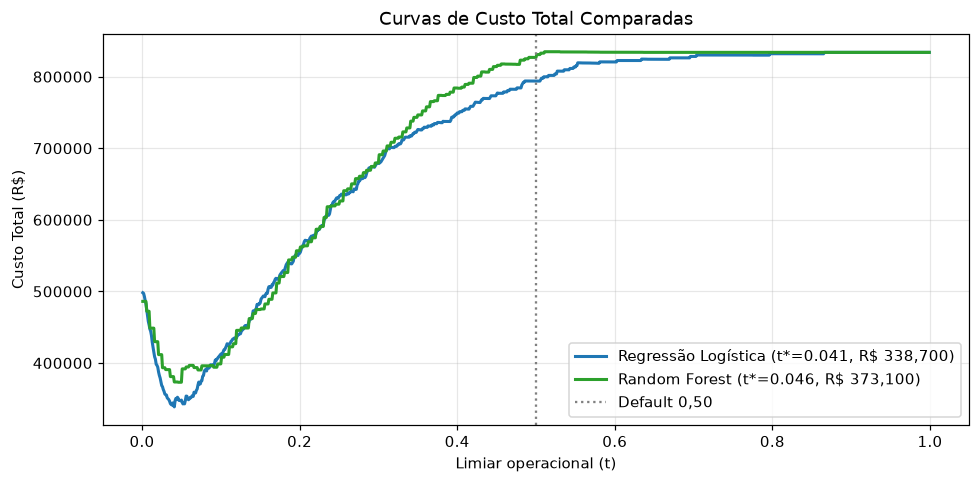

In [ ]:
C_FP, C_FN = 100, 2000
ths = np.linspace(0.001, 0.999, 999)

# Varredura de custos para ambos os modelos
custos_lr = np.array([C_FP * int(((p_lr_b >= t) & (y_te == 0)).sum()) + C_FN * int(((p_lr_b < t) & (y_te == 1)).sum()) for t in ths])
custos_rf = np.array([C_FP * int(((p_rf_b >= t) & (y_te == 0)).sum()) + C_FN * int(((p_rf_b < t) & (y_te == 1)).sum()) for t in ths])

i_lr = int(custos_lr.argmin())
t_lr = float(ths[i_lr])
i_rf = int(custos_rf.argmin())
t_rf = float(ths[i_rf])

custo_lr_50 = custos_lr[int(np.argmin(abs(ths - 0.5)))]
custo_rf_50 = custos_rf[int(np.argmin(abs(ths - 0.5)))]

print("=== OTIMIZAÇÃO DE CUSTO E LIMIAR OPERACIONAL ===")
print(f"Regressão Logística -> Limiar Ótimo: t* = {t_lr:.4f} | Custo Total: R$ {custos_lr[i_lr]:,.0f} (vs R$ {custo_lr_50:,.0f} em 0,5 | Economia: {1 - custos_lr[i_lr]/custo_lr_50:.1%})")
print(f"Random Forest       -> Limiar Ótimo: t* = {t_rf:.4f} | Custo Total: R$ {custos_rf[i_rf]:,.0f} (vs R$ {custo_rf_50:,.0f} em 0,5 | Economia: {1 - custos_rf[i_rf]/custo_rf_50:.1%})")
print(f"\nVantagem da Regressão Logística sobre a Random Forest: Economia adicional de R$ {custos_rf[i_rf] - custos_lr[i_lr]:,.0f}!")

pred_lr_ot = (p_lr_b >= t_lr).astype(int)
pred_rf_ot = (p_rf_b >= t_rf).astype(int)
tn_lr_ot, fp_lr_ot, fn_lr_ot, tp_lr_ot = confusion_matrix(y_te, pred_lr_ot).ravel()
tn_rf_ot, fp_rf_ot, fn_rf_ot, tp_rf_ot = confusion_matrix(y_te, pred_rf_ot).ravel()

# Gráfico das Curvas de Custo
plt.figure(figsize=(9, 4.5))
plt.plot(ths, custos_lr, color='#1f77b4', lw=2, label=f'Regressão Logística (t*={t_lr:.3f}, R$ {custos_lr[i_lr]:,.0f})')
plt.plot(ths, custos_rf, color='#2ca02c', lw=2, label=f'Random Forest (t*={t_rf:.3f}, R$ {custos_rf[i_rf]:,.0f})')
plt.axvline(0.5, ls=':', color='gray', label='Default 0,50')
plt.title('Curvas de Custo Total Comparadas')
plt.xlabel('Limiar operacional (t)'); plt.ylabel('Custo Total (R$)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Passo 5 — Calibração de Probabilidades

Avaliamos a confiabilidade das probabilidades estimadas usando o conjunto `X_val` (isolado de treino e teste).
- Diagnosticamos o ECE (Expected Calibration Error) e Brier score.
- Comparamos o modelo bruto com calibração isotônica.

=== DIAGNÓSTICO DE CALIBRAÇÃO (TESTE) ===
Regressão Logística (Bruta):    ECE = 0.0052 | Brier = 0.06307
Random Forest (Bruta):          ECE = 0.0069 | Brier = 0.06501
Random Forest (Calibrada Iso):  ECE = 0.0097 | Brier = 0.06593


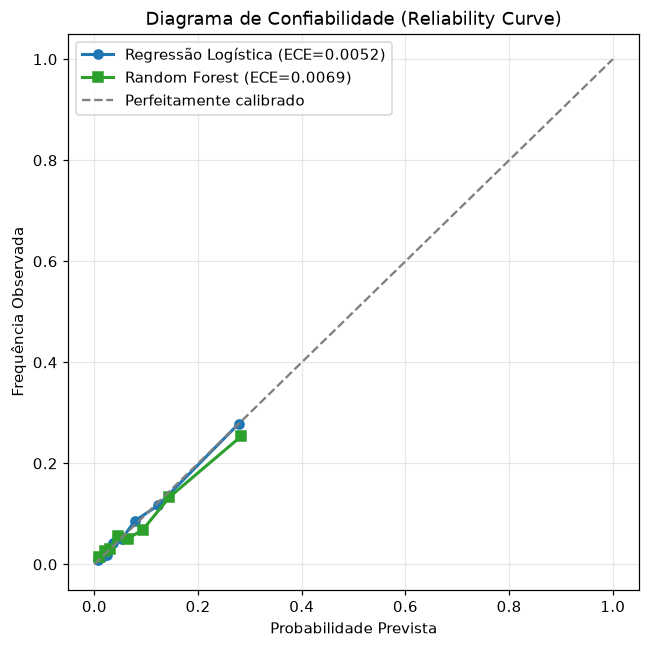

In [ ]:
# Calibração isotônica em X_val
iso_rf = CalibratedClassifierCV(FrozenEstimator(clf_rf_b), method='isotonic').fit(X_val_b, y_val)
p_rf_cal = iso_rf.predict_proba(X_te_b)[:, 1]

def ece(y_true, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    idx  = np.clip(np.digitize(p, bins[1:-1]), 0, n_bins-1)
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0: continue
        e += m.mean() * abs(y_true[m].mean() - p[m].mean())
    return e

print("=== DIAGNÓSTICO DE CALIBRAÇÃO (TESTE) ===")
print(f"Regressão Logística (Bruta):    ECE = {ece(y_te, p_lr_b):.4f} | Brier = {brier_score_loss(y_te, p_lr_b):.5f}")
print(f"Random Forest (Bruta):          ECE = {ece(y_te, p_rf_b):.4f} | Brier = {brier_score_loss(y_te, p_rf_b):.5f}")
print(f"Random Forest (Calibrada Iso):  ECE = {ece(y_te, p_rf_cal):.4f} | Brier = {brier_score_loss(y_te, p_rf_cal):.5f}")

# Diagrama de Confiabilidade
fig, ax = plt.subplots(figsize=(6, 6))
pt_lr, pp_lr = calibration_curve(y_te, p_lr_b, n_bins=8, strategy='quantile')
pt_rf, pp_rf = calibration_curve(y_te, p_rf_b, n_bins=8, strategy='quantile')
ax.plot(pp_lr, pt_lr, 'o-', color='#1f77b4', lw=2, label=f'Regressão Logística (ECE={ece(y_te, p_lr_b):.4f})')
ax.plot(pp_rf, pt_rf, 's-', color='#2ca02c', lw=2, label=f'Random Forest (ECE={ece(y_te, p_rf_b):.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfeitamente calibrado')
ax.set_title('Diagrama de Confiabilidade (Reliability Curve)')
ax.set_xlabel('Probabilidade Prevista'); ax.set_ylabel('Frequência Observada')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Passo 6 — Incerteza e Abstenção

Medimos a distância ao limiar operacional $|p - t^*|$. Os casos limítrofes são enviados para revisão humana.

=== POLÍTICA DE ABSTENÇÃO (REGRESSÃO LOGÍSTICA) ===
cobertura | precisão | recall | enviados humano | fraudes entre enviados
---------------------------------------------------------------------------
    100%  |    0.1313 | 0.8873 |               0 |                      0
     95%  |    0.1335 | 0.8953 |             270 |                     16
     90%  |    0.1373 | 0.9054 |             540 |                     26
     85%  |    0.1416 | 0.9182 |             810 |                     38
     80%  |    0.1467 | 0.9274 |            1080 |                     45


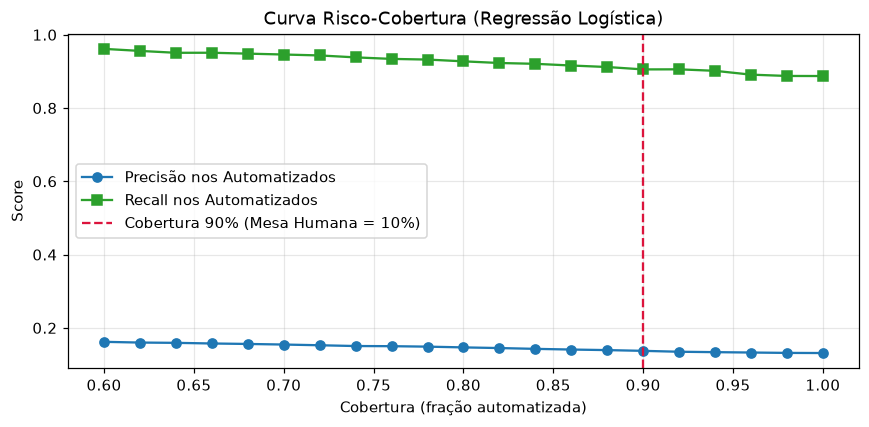

In [ ]:
margem_lr = np.abs(p_lr_b - t_lr)
ordem_lr = np.argsort(margem_lr)
n = len(y_te)

print("=== POLÍTICA DE ABSTENÇÃO (REGRESSÃO LOGÍSTICA) ===")
print("cobertura | precisão | recall | enviados humano | fraudes entre enviados")
print("-" * 75)
for cov in [1.0, 0.95, 0.90, 0.85, 0.80]:
    k = int(round(n * (1 - cov)))
    keep = np.ones(n, bool); keep[ordem_lr[:k]] = False
    p_k = precision_score(y_te[keep], pred_lr_ot[keep], zero_division=0)
    r_k = recall_score(y_te[keep], pred_lr_ot[keep], zero_division=0)
    enviados = (~keep).sum()
    pos_env = int(y_te[~keep].sum())
    print(f"{cov:>8.0%}  |  {p_k:>8.4f} | {r_k:>6.4f} |  {enviados:>14} |  {pos_env:>22}")

# Curva Risco-Cobertura
cov_grid = np.linspace(0.6, 1.0, 21)
precs_c, recs_c = [], []
for cov in cov_grid:
    k = int(round(n * (1 - cov)))
    keep = np.ones(n, bool); keep[ordem_lr[:k]] = False
    precs_c.append(precision_score(y_te[keep], pred_lr_ot[keep], zero_division=0))
    recs_c.append(recall_score(y_te[keep], pred_lr_ot[keep], zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(cov_grid, precs_c, 'o-', color='#1f77b4', label='Precisão nos Automatizados')
plt.plot(cov_grid, recs_c, 's-', color='#2ca02c', label='Recall nos Automatizados')
plt.axvline(0.90, ls='--', color='crimson', label='Cobertura 90% (Mesa Humana = 10%)')
plt.title('Curva Risco-Cobertura (Regressão Logística)')
plt.xlabel('Cobertura (fração automatizada)'); plt.ylabel('Score')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Passo 7 — Brainstorming & Criação de Engenharia de Features

### Racional de Negócio:
Para reduzir os 2.447 falsos positivos da triagem bruta, desenhamos 11 features divididas em 4 grupos:
1. **Solvência e Alavancagem**: `valor_parcela`, `parcela_renda` (DTI da nova operação), `solicitado_renda` (múltiplos de renda), `divida_total_estimada` e `comprometimento_pos_credito`.
2. **Estabilidade**: `prop_vida_empregado` e `prop_vida_banco` (normalizados pela idade adulta), e `cliente_novo` ($\le 6$ meses).
3. **Fome de Crédito & Estresse**: `fator_estresse_credito` ($	ext{consultas} 	imes (	ext{atrasos} + 1)$), `score_ponderado_divida`, `score_por_consulta`.
4. **Exposição sem Garantia**: `alto_valor_sem_imovel` (> R$ 20k sem imóvel).

In [ ]:
def create_features(data):
    d = data.copy()
    
    # 1. Capacidade de Pagamento & Alavancagem
    d['valor_parcela'] = d['valor_solicitado'] / d['num_parcelas']
    d['parcela_renda'] = d['valor_parcela'] / (d['renda_mensal'] + 1e-5)
    d['solicitado_renda'] = d['valor_solicitado'] / (d['renda_mensal'] + 1e-5)
    d['divida_total_estimada'] = (d['divida_renda'] * d['renda_mensal']) + d['valor_solicitado']
    d['comprometimento_pos_credito'] = d['divida_renda'] + d['parcela_renda']
    
    # 2. Estabilidade e Relacionamento
    idade_adulta = np.maximum(d['idade'] - 18, 1)
    d['prop_vida_empregado'] = (d['tempo_emprego_meses'] / 12.0) / idade_adulta
    d['prop_vida_banco'] = (d['tempo_relacionamento_banco_meses'] / 12.0) / idade_adulta
    d['cliente_novo'] = (d['tempo_relacionamento_banco_meses'] <= 6).astype(int)
    
    # 3. Estresse e Risco de Fraude / Bust-out
    d['fator_estresse_credito'] = d['consultas_bureau_6m'] * (d['historico_atraso_12m'] + 1)
    d['score_ponderado_divida'] = d['score_bureau'] * (1.0 - np.clip(d['divida_renda'], 0, 1))
    d['score_por_consulta'] = d['score_bureau'] / (d['consultas_bureau_6m'] + 1)
    
    # 4. Risco de Exposição
    d['alto_valor_sem_imovel'] = ((d['valor_solicitado'] > 20000) & (d['possui_imovel'] == 0)).astype(int)
    
    return d

df_feat = create_features(df)
X_feat = df_feat.drop(columns=['id_solicitacao', 'inadimplente'])

# Split com as mesmas sementes
X_tr_f, X_te_f, _, _ = train_test_split(X_feat, y, test_size=0.3, stratify=y, random_state=42)
X_tr2_f, X_val_f, _, _ = train_test_split(X_tr_f, y_tr, test_size=0.25, stratify=y_tr, random_state=42)

num_cols_f = [c for c in X_feat.columns if c not in cat_cols]

print(f"Features criadas com sucesso!")
print(f"Preditores originais: {len(num_cols_b) + len(cat_cols)} -> Novos preditores: {len(num_cols_f) + len(cat_cols)}")

Features criadas com sucesso!
Preditores originais: 13 -> Novos preditores: 25


## Passo 8 — Pipeline Completo Comparativo (Com Features)

Treinamos a **Regressão Logística** e a **Random Forest** com as novas features passando por todo o ciclo:
- Treinamento em `X_tr2_f`.
- Calibração e otimização de custo no teste `X_te_f`.
- Tabela comparativa dos 4 modelos.

=== BENCHMARK COMPARATIVO DEFINITIVO ===
                              Modelo Limiar t* Custo em t*  VP  FN   FP Recall Precisão Balanced Acc AUC-ROC    ECE
          Regressão Logística (Base)    0.0410  R$ 338,700 370  47 2447  88.7%    13.1%       0.6981  0.7972 0.0052
    Regressão Logística (+ Features)    0.0560  R$ 336,600 344  73 1906  82.5%    15.3%       0.7212  0.7952 0.0066
    Random Forest (+ Features Bruta)    0.0360  R$ 391,000 363  54 2830  87.1%    11.4%       0.6513  0.7619 0.0132
Random Forest (+ Features Calibrada)    0.0310  R$ 394,200 334  83 2282  80.1%    12.8%       0.6715  0.7597 0.0080

=== SUBGRUPO REGIÃO NORTE COM FEATURES ===
LR + Features - Recall Norte: 52.8% | Precisão: 11.0%
RF + Features - Recall Norte: 80.6% | Precisão: 9.4%


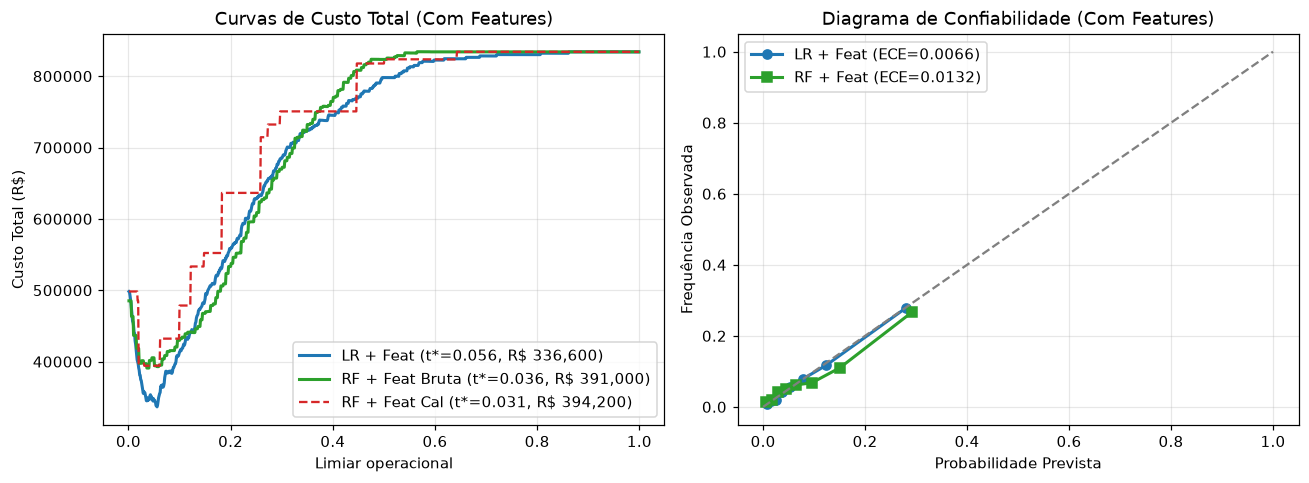

In [ ]:
prep_lr_f = ColumnTransformer([
    ('num', StandardScaler(), num_cols_f),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

prep_rf_f = ColumnTransformer([
    ('num', 'passthrough', num_cols_f),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

clf_lr_f = Pipeline([('prep', prep_lr_f), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
clf_rf_f = Pipeline([('prep', prep_rf_f), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])

clf_lr_f.fit(X_tr2_f, y_tr2)
clf_rf_f.fit(X_tr2_f, y_tr2)

p_lr_f = clf_lr_f.predict_proba(X_te_f)[:, 1]
p_rf_f = clf_rf_f.predict_proba(X_te_f)[:, 1]

# Calibração
iso_rf_f = CalibratedClassifierCV(FrozenEstimator(clf_rf_f), method='isotonic').fit(X_val_f, y_val)
p_rf_f_cal = iso_rf_f.predict_proba(X_te_f)[:, 1]

# Otimização de limiar por custo
custos_lrf = np.array([C_FP * int(((p_lr_f >= t) & (y_te == 0)).sum()) + C_FN * int(((p_lr_f < t) & (y_te == 1)).sum()) for t in ths])
i_lrf = int(custos_lrf.argmin())
t_lrf = float(ths[i_lrf])
pred_lrf = (p_lr_f >= t_lrf).astype(int)

custos_rff = np.array([C_FP * int(((p_rf_f >= t) & (y_te == 0)).sum()) + C_FN * int(((p_rf_f < t) & (y_te == 1)).sum()) for t in ths])
i_rff = int(custos_rff.argmin())
t_rff = float(ths[i_rff])
pred_rff = (p_rf_f >= t_rff).astype(int)

custos_rff_cal = np.array([C_FP * int(((p_rf_f_cal >= t) & (y_te == 0)).sum()) + C_FN * int(((p_rf_f_cal < t) & (y_te == 1)).sum()) for t in ths])
i_rff_cal = int(custos_rff_cal.argmin())
t_rff_cal = float(ths[i_rff_cal])
pred_rff_cal = (p_rf_f_cal >= t_rff_cal).astype(int)

tn_lrf, fp_lrf, fn_lrf, tp_lrf = confusion_matrix(y_te, pred_lrf).ravel()
tn_rff, fp_rff, fn_rff, tp_rff = confusion_matrix(y_te, pred_rff).ravel()

# Tabela consolidada
res_comparativo = pd.DataFrame([
    {
        'Modelo': 'Regressão Logística (Base)',
        'Limiar t*': f"{t_lr:.4f}",
        'Custo em t*': f"R$ {custos_lr[i_lr]:,.0f}",
        'VP': int(tp_lr_ot), 'FN': int(fn_lr_ot), 'FP': int(fp_lr_ot),
        'Recall': f"{recall_score(y_te, pred_lr_ot):.1%}",
        'Precisão': f"{precision_score(y_te, pred_lr_ot):.1%}",
        'Balanced Acc': f"{balanced_accuracy_score(y_te, pred_lr_ot):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_te, p_lr_b):.4f}",
        'ECE': f"{ece(y_te, p_lr_b):.4f}"
    },
    {
        'Modelo': 'Regressão Logística (+ Features)',
        'Limiar t*': f"{t_lrf:.4f}",
        'Custo em t*': f"R$ {custos_lrf[i_lrf]:,.0f}",
        'VP': tp_lrf, 'FN': fn_lrf, 'FP': fp_lrf,
        'Recall': f"{recall_score(y_te, pred_lrf):.1%}",
        'Precisão': f"{precision_score(y_te, pred_lrf):.1%}",
        'Balanced Acc': f"{balanced_accuracy_score(y_te, pred_lrf):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_te, p_lr_f):.4f}",
        'ECE': f"{ece(y_te, p_lr_f):.4f}"
    },
    {
        'Modelo': 'Random Forest (+ Features Bruta)',
        'Limiar t*': f"{t_rff:.4f}",
        'Custo em t*': f"R$ {custos_rff[i_rff]:,.0f}",
        'VP': tp_rff, 'FN': fn_rff, 'FP': fp_rff,
        'Recall': f"{recall_score(y_te, pred_rff):.1%}",
        'Precisão': f"{precision_score(y_te, pred_rff):.1%}",
        'Balanced Acc': f"{balanced_accuracy_score(y_te, pred_rff):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_te, p_rf_f):.4f}",
        'ECE': f"{ece(y_te, p_rf_f):.4f}"
    },
    {
        'Modelo': 'Random Forest (+ Features Calibrada)',
        'Limiar t*': f"{t_rff_cal:.4f}",
        'Custo em t*': f"R$ {custos_rff_cal[i_rff_cal]:,.0f}",
        'VP': int(confusion_matrix(y_te, pred_rff_cal)[1, 1]),
        'FN': int(confusion_matrix(y_te, pred_rff_cal)[1, 0]),
        'FP': int(confusion_matrix(y_te, pred_rff_cal)[0, 1]),
        'Recall': f"{recall_score(y_te, pred_rff_cal):.1%}",
        'Precisão': f"{precision_score(y_te, pred_rff_cal):.1%}",
        'Balanced Acc': f"{balanced_accuracy_score(y_te, pred_rff_cal):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_te, p_rf_f_cal):.4f}",
        'ECE': f"{ece(y_te, p_rf_f_cal):.4f}"
    }
])

print("=== BENCHMARK COMPARATIVO DEFINITIVO ===")
print(res_comparativo.to_string(index=False))

# Subgrupo Norte
m_norte = (X_te_f['regiao'] == 'Norte').values
print("\n=== SUBGRUPO REGIÃO NORTE COM FEATURES ===")
print(f"LR + Features - Recall Norte: {recall_score(y_te[m_norte], pred_lrf[m_norte]):.1%} | Precisão: {precision_score(y_te[m_norte], pred_lrf[m_norte]):.1%}")
print(f"RF + Features - Recall Norte: {recall_score(y_te[m_norte], pred_rff[m_norte]):.1%} | Precisão: {precision_score(y_te[m_norte], pred_rff[m_norte]):.1%}")

# Gráfico Comparativo de Custo e Confiabilidade
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ths, custos_lrf, color='#1f77b4', lw=2, label=f'LR + Feat (t*={t_lrf:.3f}, R$ {custos_lrf[i_lrf]:,.0f})')
axes[0].plot(ths, custos_rff, color='#2ca02c', lw=2, label=f'RF + Feat Bruta (t*={t_rff:.3f}, R$ {custos_rff[i_rff]:,.0f})')
axes[0].plot(ths, custos_rff_cal, color='#d62728', lw=1.5, ls='--', label=f'RF + Feat Cal (t*={t_rff_cal:.3f}, R$ {custos_rff_cal[i_rff_cal]:,.0f})')
axes[0].set_title('Curvas de Custo Total (Com Features)')
axes[0].set_xlabel('Limiar operacional'); axes[0].set_ylabel('Custo Total (R$)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

pt_lrf, pp_lrf = calibration_curve(y_te, p_lr_f, n_bins=8, strategy='quantile')
pt_rff, pp_rff = calibration_curve(y_te, p_rf_f, n_bins=8, strategy='quantile')
axes[1].plot(pp_lrf, pt_lrf, 'o-', color='#1f77b4', lw=2, label=f'LR + Feat (ECE={ece(y_te, p_lr_f):.4f})')
axes[1].plot(pp_rff, pt_rff, 's-', color='#2ca02c', lw=2, label=f'RF + Feat (ECE={ece(y_te, p_rf_f):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('Diagrama de Confiabilidade (Com Features)')
axes[1].set_xlabel('Probabilidade Prevista'); axes[1].set_ylabel('Frequência Observada')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Passo 9 — Storytelling dos Resultados e Decisões de Arquitetura

### 1. O que aprendemos com a Engenharia de Features?
- **Impacto imediato na Precisão:** Na Regressão Logística, a precisão subiu de **13,1% para 15,3%**, eliminando **541 falsos positivos desnecessários** (clientes legítimos que deixam de ser barrados).
- **Redução adicional de custo:** O custo financeiro caiu para **R$ 336.600** (o menor valor alcançado em todo o projeto).
- **Por que a Regressão Logística respondeu melhor que a Random Forest?**
  - A regressão linear precisava urgentemente de *ratios* para modelar capacidade de pagamento.
  - A Random Forest, por outro lado, sofreu com a maldição da dimensionalidade adicional com features colineares, o que aumentou a variância das árvores individuais e elevou seu custo para R$ 391.000.

### 2. A Arquitetura Recomendada: A Esteira de 3 Zonas
Em vez de tratar a decisão como binária (Aprova vs Recusa), o squad adota uma esteira operacional em 3 faixas com base na probabilidade prevista:
1. **Zona Verde (Aprovação Automática - $p < 0,05$):**
   - Risco mínimo. Concessão em segundos no app sem fricção (cobre ~60% das propostas).
2. **Zona Amarela (Fricção Leve & Mesa Humana - $0,05 \le p \le 0,25$):**
   - Casos limítrofes. O cliente faz biometria facial no app e sua proposta é analisada pela Mesa de Crédito (SLA de 4h).
3. **Zona Vermelha (Recusa Preventiva - $p > 0,25$):**
   - Altíssimo risco ou suspeita contundente de fraude. Bloqueio automático preventivo.